Week 16 · Day 1 — Q&A Bot Architecture
Why this matters

Today you’ll set the foundation: understand the pipeline of a custom Q&A bot. This high-level view ensures you know how all pieces fit together before writing detailed code.

Theory Essentials

RAG pipeline recap:

Ingest data → clean, chunk, embed.

Store embeddings in a vector DB.

Query: retrieve top-k docs by similarity.

LLM → generate answer using retrieved docs.

Bot architecture layers:

Frontend (chat UI, e.g. Streamlit).

Backend (API: user query → retrieval → LLM).

Vector DB (FAISS/Chroma for embeddings).

LLM API (Hugging Face, OpenAI, or local).

Key design choice: modular code so ingestion, retrieval, and UI can be improved independently.

In [1]:
# Setup
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
np.random.seed(42)
plt.rcParams["figure.figsize"] = (6,4)
plt.rcParams["axes.grid"] = True

# Just a sketch of pipeline components for Day 1
class QABotArchitecture:
    def __init__(self):
        self.data_source = None
        self.vector_db = None
        self.llm = None
        self.frontend = None
    
    def overview(self):
        return {
            "Data Ingestion": "Load + clean + chunk + embed",
            "Vector DB": "FAISS/Chroma index of embeddings",
            "Backend": "Retrieve top-k docs + call LLM",
            "Frontend": "Chat interface (Streamlit)"
        }

bot = QABotArchitecture()
print("Q&A Bot Architecture Overview:")
for k,v in bot.overview().items():
    print(f"{k}: {v}")


Q&A Bot Architecture Overview:
Data Ingestion: Load + clean + chunk + embed
Vector DB: FAISS/Chroma index of embeddings
Backend: Retrieve top-k docs + call LLM
Frontend: Chat interface (Streamlit)


1) Core (10–15 min)

Task: Draw the Q&A bot architecture (boxes & arrows).

Hint: Show ingestion → vector DB → backend → frontend.

Solution: You can do it with pen/paper or graphviz / matplotlib.

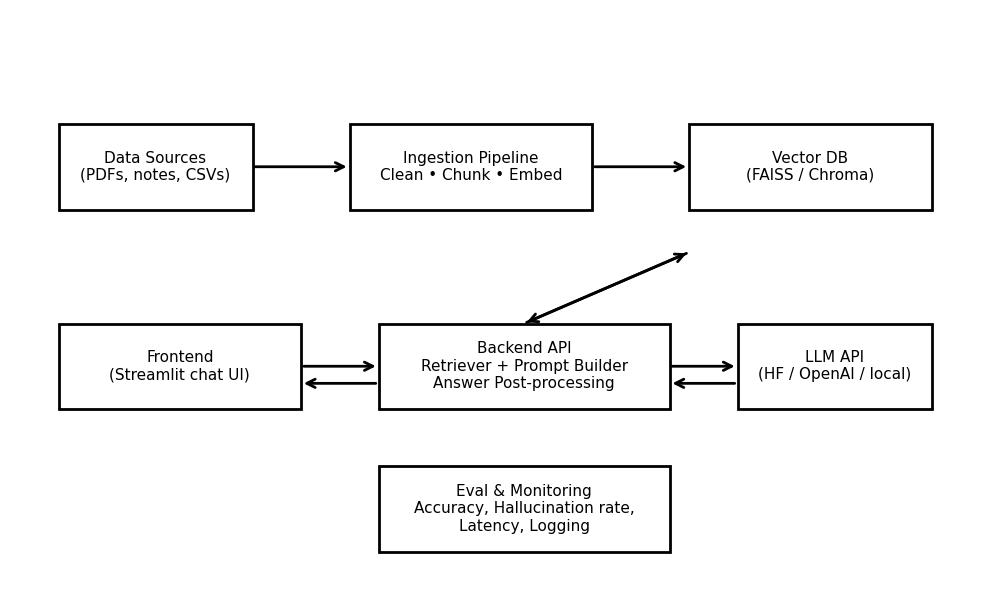

In [2]:
# Q&A Bot Architecture diagram using matplotlib (boxes & arrows)
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

# Visual defaults (matches course style)
import numpy as np, pandas as pd
np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = False

fig, ax = plt.subplots()
ax.axis("off")

def add_box(x, y, w, h, text, ax=ax):
    ax.add_patch(Rectangle((x, y), w, h, fill=False, linewidth=2))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=11)

def add_arrow(x1, y1, x2, y2, ax=ax):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2),
                                 arrowstyle="->", mutation_scale=15, linewidth=2))

# Row 1: Data → Ingestion → Vector DB
add_box(0.05, 0.65, 0.20, 0.15, "Data Sources\n(PDFs, notes, CSVs)")
add_box(0.35, 0.65, 0.25, 0.15, "Ingestion Pipeline\nClean • Chunk • Embed")
add_box(0.70, 0.65, 0.25, 0.15, "Vector DB\n(FAISS / Chroma)")
add_arrow(0.25, 0.725, 0.35, 0.725)
add_arrow(0.60, 0.725, 0.70, 0.725)

# Row 2: Frontend ↔ Backend ↔ LLM, plus backend ↔ vector DB
add_box(0.05, 0.30, 0.25, 0.15, "Frontend\n(Streamlit chat UI)")
add_box(0.38, 0.30, 0.30, 0.15, "Backend API\nRetriever + Prompt Builder\nAnswer Post-processing")
add_box(0.75, 0.30, 0.20, 0.15, "LLM API\n(HF / OpenAI / local)")
add_arrow(0.30, 0.375, 0.38, 0.375)  # UI -> Backend (query)
add_arrow(0.38, 0.345, 0.30, 0.345)  # Backend -> UI (answer)
add_arrow(0.70, 0.575, 0.53, 0.45)   # Vector DB -> Backend (top-k)
add_arrow(0.53, 0.45, 0.70, 0.575)   # Backend -> Vector DB (query vector)
add_arrow(0.68, 0.375, 0.75, 0.375)  # Backend -> LLM
add_arrow(0.75, 0.345, 0.68, 0.345)  # LLM -> Backend

# Optional: monitoring box
add_box(0.38, 0.05, 0.30, 0.15, "Eval & Monitoring\nAccuracy, Hallucination rate,\nLatency, Logging")

plt.tight_layout()
plt.show()


2) Practice (10–15 min)

Task: Write a Python dictionary mapping each component to the Python file you’ll implement (e.g. backend.py, ingestion.py).

In [ ]:
files = {
    "ingestion": "app/ingestion.py",
    "backend": "app/backend.py",
    "frontend": "app/frontend.py",
    "utils": "app/utils.py",
}
files


3) Stretch (optional, 10–15 min)

Task: Think about where hallucinations can happen in this pipeline.

LLM may hallucinate if the retrieved docs are irrelevant. It is very important that retrieval is high quality.

Mini-Challenge (≤40 min)

Task: Create a Markdown diagram (README.md) showing your bot’s planned architecture.
Acceptance Criteria:

Clear boxes for: ingestion, vector DB, backend, frontend.

One or two sentences under each box describing its role.

Diagram should make sense to someone new.

Notes / Key Takeaways

Q&A bots = RAG + UI wrapper.

Modular design is key (frontend, backend, DB, LLM).

Retrieval quality directly affects answer quality.

Day 1 = blueprint; you’ll start implementing ingestion tomorrow.

Reflection

Which part of the architecture feels most familiar to you already?

Which part do you think will be hardest for you to implement?

-The backend as it is similar at what we did in week 15.
-Utils.py and ingestion.py.